In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import system components
from soros_system.main import TrendAnalyzer
from soros_system.analysis.markov_vol_model import MarkovVolModel
from soros_system.analysis.forward_returns.signal_evaluator import SignalEvaluator
from soros_system.analysis.forward_returns.statistical_tests import StatisticalTester
from soros_system.portfolio.signal_selector import SignalSelector

# Import all signal classes
from soros_system.signals.trend_signals import (
    # USD Quote Trend Signals
    ShortTermStrongBearUSD, ShortTermWeakBearUSD, ShortTermNeutralUSD, ShortTermWeakBullUSD, ShortTermStrongBullUSD,
    MediumTermStrongBearUSD, MediumTermWeakBearUSD, MediumTermNeutralUSD, MediumTermWeakBullUSD, MediumTermStrongBullUSD,
    LongTermStrongBearUSD, LongTermWeakBearUSD, LongTermNeutralUSD, LongTermWeakBullUSD, LongTermStrongBullUSD,
    OverallStrongBearUSD, OverallWeakBearUSD, OverallNeutralUSD, OverallWeakBullUSD, OverallStrongBullUSD,
    # BTC Quote Trend Signals
    ShortTermStrongBearBTC, ShortTermWeakBearBTC, ShortTermNeutralBTC, ShortTermWeakBullBTC, ShortTermStrongBullBTC,
    MediumTermStrongBearBTC, MediumTermWeakBearBTC, MediumTermNeutralBTC, MediumTermWeakBullBTC, MediumTermStrongBullBTC,
    LongTermStrongBearBTC, LongTermWeakBearBTC, LongTermNeutralBTC, LongTermWeakBullBTC, LongTermStrongBullBTC,
    OverallStrongBearBTC, OverallWeakBearBTC, OverallNeutralBTC, OverallWeakBullBTC, OverallStrongBullBTC
)
from soros_system.signals.rsi_signals import (
    RSI_Oversold_USD, RSI_Overbought_USD, RSI_Bullish_USD, RSI_Bearish_USD,
    RSI_Oversold_BTC, RSI_Overbought_BTC, RSI_Bullish_BTC, RSI_Bearish_BTC
)
from soros_system.signals.volatility_signals import (
    MarkovLowVolatilitySignal, MarkovHighVolatilitySignal
)
from soros_system.signals.ssr_signals import SSR_RiskOn, SSR_RiskOff

# Set paths and initialize analyzer
data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/'
btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv'
ssr_data_path='/Users/valter.rebelo/MissionControl/data/onchainData/BTC_SSR.csv'
market_data_path="/Users/valter.rebelo/MissionControl/data/micro/assetData/"
markov_vol_model = MarkovVolModel.load_model_by_timestamp('20250325_144631')

# Initialize analyzer with test assets
test_assets = ['bitcoin', 'ethereum', 'solana']
print(f"Testing with assets: {test_assets}")

analyzer = TrendAnalyzer(
    asset_ids=test_assets,
    data_path=data_path,
    btc_data_path=btc_data_path,
    lookback_days='all',
    ssr_data_path=ssr_data_path,        
    markov_analyzer=markov_vol_model,
    market_data_path=market_data_path  
)

# Run analysis
analyzer.analyze_multiple_assets()

# Get data for Ethereum
eth_data = analyzer.get_asset_raw_data('ethereum')
print(f"\nEthereum data available from {eth_data['date'].min()} to {eth_data['date'].max()}")
print(f"Total data points: {len(eth_data)}")

Testing with assets: ['bitcoin', 'ethereum', 'solana']


Detected MarkovVolModel passed as markov_analyzer - using it for volatility analysis


Analyzing assets:   0%|          | 0/3 [00:00<?, ?it/s]

Classifying bitcoin:   0%|          | 0/1 [00:00<?, ?it/s]

Creating trend data for bitcoin:   0%|          | 0/2 [00:00<?, ?it/s]

...

Classifying solana:   0%|          | 0/1 [00:00<?, ?it/s]

Creating trend data for solana:   0%|          | 0/2 [00:00<?, ?it/s]

Computing metrics:   0%|          | 0/3 [00:00<?, ?it/s]

Column overall_trend_BTC not found in data for bitcoin. Skipping BTC trend metrics calculation.



Ethereum data available from 2015-08-07 00:00:00 to 2025-04-03 00:00:00
Total data points: 3528


In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Copy the essential fixed methods from forward returns calculator
class BinaryForwardReturnsCalculator:
    """Fixed calculator that works with binary (0/1) signals instead of (-1/1)."""
    
    def __init__(self, periods=None):
        self.periods = periods or [1, 3, 5, 7, 14, 21, 28]
    
    def calculate_forward_returns(self, data, price_col='close'):
        """Calculate forward returns for multiple periods."""
        df = data.copy()
        
        # Ensure data is sorted by date
        if 'date' in df.columns:
            df = df.sort_values('date')
        
        # Calculate forward returns for each period
        for period in self.periods:
            col_name = f'fwd_ret_{period}d'
            try:
                df[col_name] = np.nan
                for i in range(len(df) - period):
                    df.iloc[i, df.columns.get_loc(col_name)] = (
                        df.iloc[i + period][price_col] / df.iloc[i][price_col]
                    ) - 1
            except Exception as e:
                print(f"Error calculating {period}-day forward returns: {e}")
                df[col_name] = np.nan
        
        return df
    
    def get_conditional_returns(self, data, signal_series, min_samples=20):
        """Get forward returns conditioned on signal values (FIXED for 0/1 signals)."""
        df = data.copy()
        
        # Add signal column
        df['signal'] = signal_series.values
        
        # Get forward return columns
        fwd_cols = [col for col in df.columns if col.startswith('fwd_ret_')]
        
        # Initialize dictionaries
        conditional_returns = {}
        
        # Filter returns based on signal value
        # KEY FIX: Use 1 for positive and 0 for negative instead of 1/-1
        positive_signal = df[df['signal'] == 1]  # Signal is active
        negative_signal = df[df['signal'] == 0]  # Signal is inactive 
        all_signal = df
        
        # Calculate sample counts
        sample_counts = {
            'positive': len(positive_signal),
            'negative': len(negative_signal),
            'all': len(all_signal)
        }
        
        print(f"Signal distribution: {sample_counts['positive']} positive (1), "
              f"{sample_counts['negative']} negative (0), {sample_counts['all']} total")
        
        # Check if we have sufficient samples
        has_positive = sample_counts['positive'] >= min_samples
        has_negative = sample_counts['negative'] >= min_samples
        
        if not has_positive and not has_negative:
            print(f"Insufficient samples for both signal states. Need at least {min_samples}.")
        elif not has_positive:
            print(f"Insufficient samples for positive signal. Got {sample_counts['positive']}.")
        elif not has_negative:
            print(f"Insufficient samples for negative signal. Got {sample_counts['negative']}.")
        
        # Extract conditional returns for each period
        for col in fwd_cols:
            period = int(col.split('_')[2].replace('d', ''))
            period_dict = {}
            
            if has_positive:
                period_dict['positive'] = positive_signal[col].dropna()
            
            if has_negative:
                period_dict['negative'] = negative_signal[col].dropna()
            
            period_dict['all'] = all_signal[col].dropna()
            conditional_returns[period] = period_dict
        
        return conditional_returns, sample_counts

Testing with 3528 days of ethereum data
Oversold signal values: 1s: 155, 0s: 3373
Overbought signal values: 1s: 416, 0s: 3112
Bullish signal values: 1s: 1623, 0s: 1905
Bearish signal values: 1s: 1401, 0s: 2127


ANALYZING RSI Oversold SIGNAL
Signal distribution: 155 positive (1), 3373 negative (0), 3528 total
We have enough samples for analysis!

=== 3-Day Forward Returns Analysis ===
Signal=1 samples: 155, Signal=0 samples: 3370

Effectiveness Summary for 3-day period:
Overall effective: False
Confidence: 1.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: True
  P-value: 0.0482
  Mean difference: -0.0176
  Effect size: -0.1744

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0420
  Median difference: -0.0189

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0005
  Statistic: 0.1651

Skewness & Kurtosis:
  Signal=1 skew: 0.2656
  Signal=0 skew: 2.3393
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


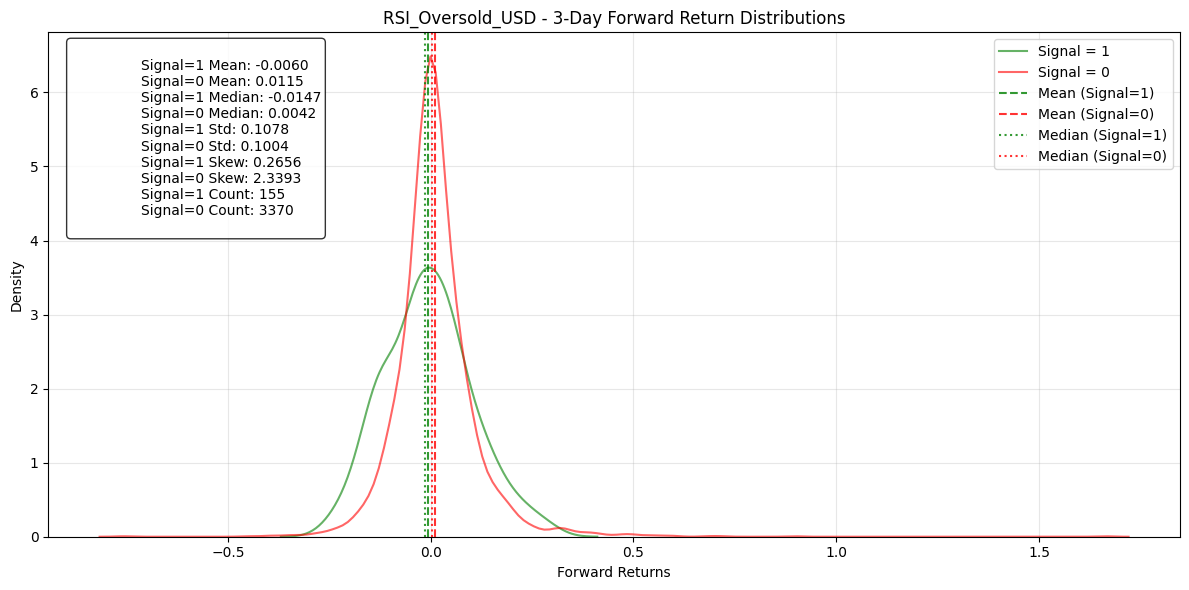


=== 5-Day Forward Returns Analysis ===
Signal=1 samples: 155, Signal=0 samples: 3368

Effectiveness Summary for 5-day period:
Overall effective: False
Confidence: 0.3333
Effect size: 0.0000

T-test (mean comparison):
  Significant: False
  P-value: 0.1463
  Mean difference: -0.0171
  Effect size: -0.1286

Mann-Whitney (distribution comparison):
  Significant: False
  P-value: 0.1750
  Median difference: -0.0106

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0347
  Statistic: 0.1157

Skewness & Kurtosis:
  Signal=1 skew: 0.9038
  Signal=0 skew: 2.0388
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


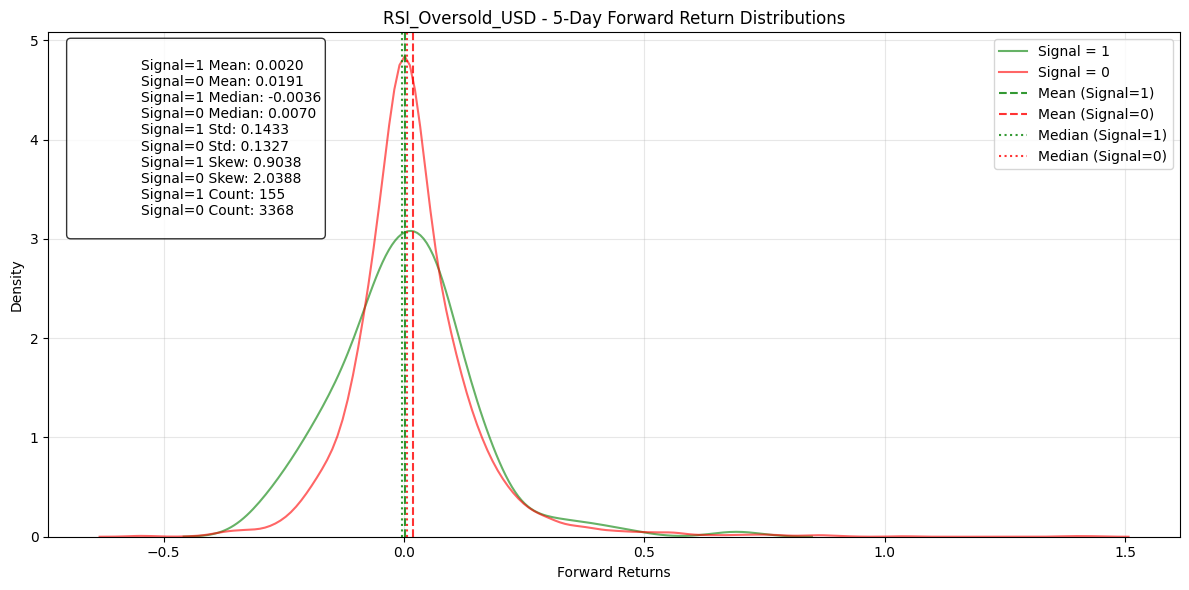


=== 7-Day Forward Returns Analysis ===
Signal=1 samples: 155, Signal=0 samples: 3366

Effectiveness Summary for 7-day period:
Overall effective: False
Confidence: 0.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: False
  P-value: 0.3217
  Mean difference: -0.0162
  Effect size: -0.1008

Mann-Whitney (distribution comparison):
  Significant: False
  P-value: 0.1242
  Median difference: -0.0117

Kolmogorov-Smirnov (distribution shape):
  Significant: False
  P-value: 0.0995
  Statistic: 0.0994

Skewness & Kurtosis:
  Signal=1 skew: 2.4656
  Signal=0 skew: 1.8584
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


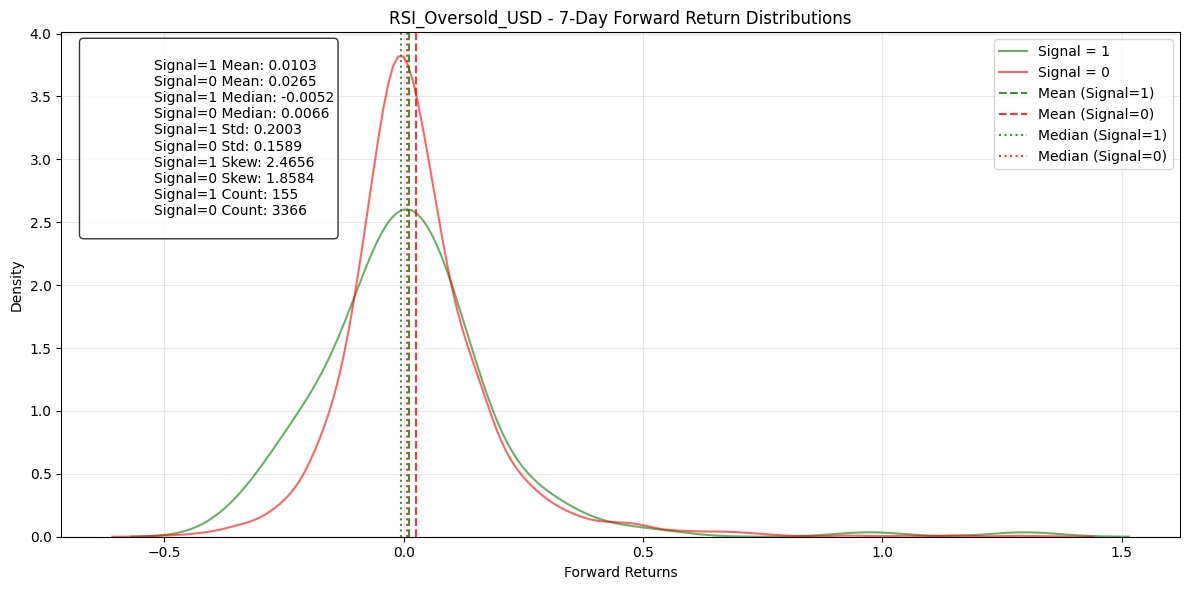


=== 14-Day Forward Returns Analysis ===
Signal=1 samples: 155, Signal=0 samples: 3359

Effectiveness Summary for 14-day period:
Overall effective: False
Confidence: 0.3333
Effect size: 0.0000

T-test (mean comparison):
  Significant: False
  P-value: 0.2587
  Mean difference: -0.0256
  Effect size: -0.1020

Mann-Whitney (distribution comparison):
  Significant: False
  P-value: 0.0667
  Median difference: -0.0298

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0020
  Statistic: 0.1513

Skewness & Kurtosis:
  Signal=1 skew: 1.4341
  Signal=0 skew: 1.9252
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


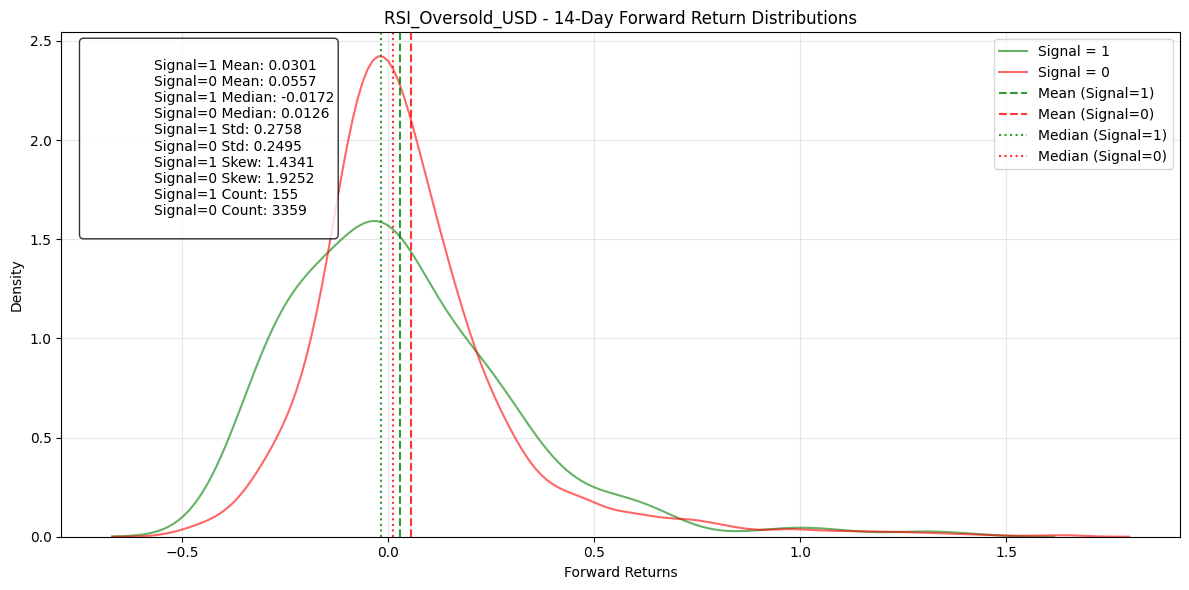


=== 30-Day Forward Returns Analysis ===
Signal=1 samples: 155, Signal=0 samples: 3343

Effectiveness Summary for 30-day period:
Overall effective: False
Confidence: 0.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: False
  P-value: 0.7395
  Mean difference: -0.0104
  Effect size: -0.0209

Mann-Whitney (distribution comparison):
  Significant: False
  P-value: 0.3380
  Median difference: 0.0207

Kolmogorov-Smirnov (distribution shape):
  Significant: False
  P-value: 0.2378
  Statistic: 0.0836

Skewness & Kurtosis:
  Signal=1 skew: 0.7176
  Signal=0 skew: 2.9018
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


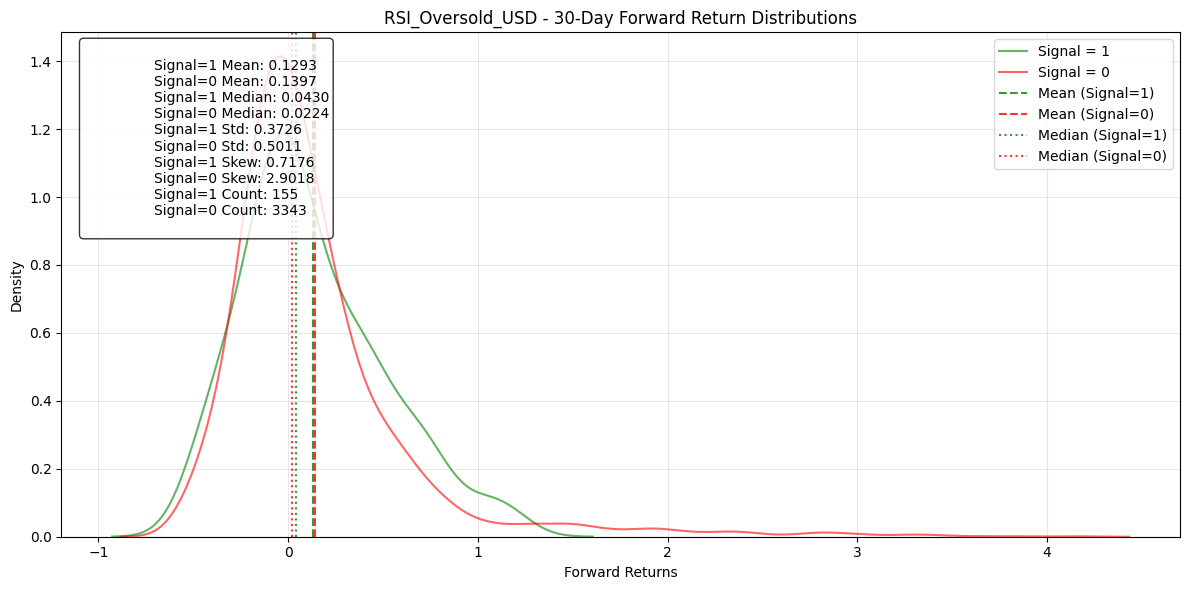


=== OVERALL SUMMARY ===
Signal: RSI_Oversold_USD
Effective periods: 0/5
Effectiveness ratio: 0.0000
Average effect size: 0.0000
Average confidence: 0.0000
Average mean difference: 0.0000
Overall effectiveness: False
Weight: 0.0000


ANALYZING RSI Overbought SIGNAL
Signal distribution: 416 positive (1), 3112 negative (0), 3528 total
We have enough samples for analysis!

=== 3-Day Forward Returns Analysis ===
Signal=1 samples: 416, Signal=0 samples: 3109

Effectiveness Summary for 3-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.2871

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0288
  Effect size: 0.2871

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0001
  Median difference: 0.0126

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1403

Skewness & Kurtosis:
  Signal=1 skew: 1.4816
  Signal=0 skew: 2.3412
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


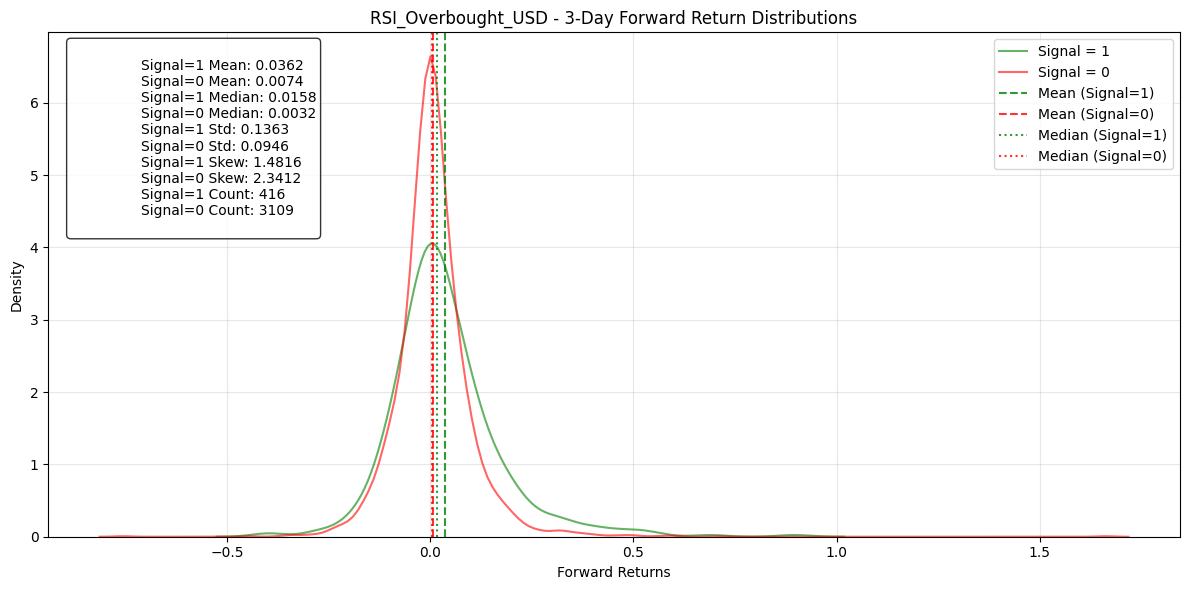


=== 5-Day Forward Returns Analysis ===
Signal=1 samples: 416, Signal=0 samples: 3107

Effectiveness Summary for 5-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.3204

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0425
  Effect size: 0.3204

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0001
  Median difference: 0.0178

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1605

Skewness & Kurtosis:
  Signal=1 skew: 1.3139
  Signal=0 skew: 2.0495
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


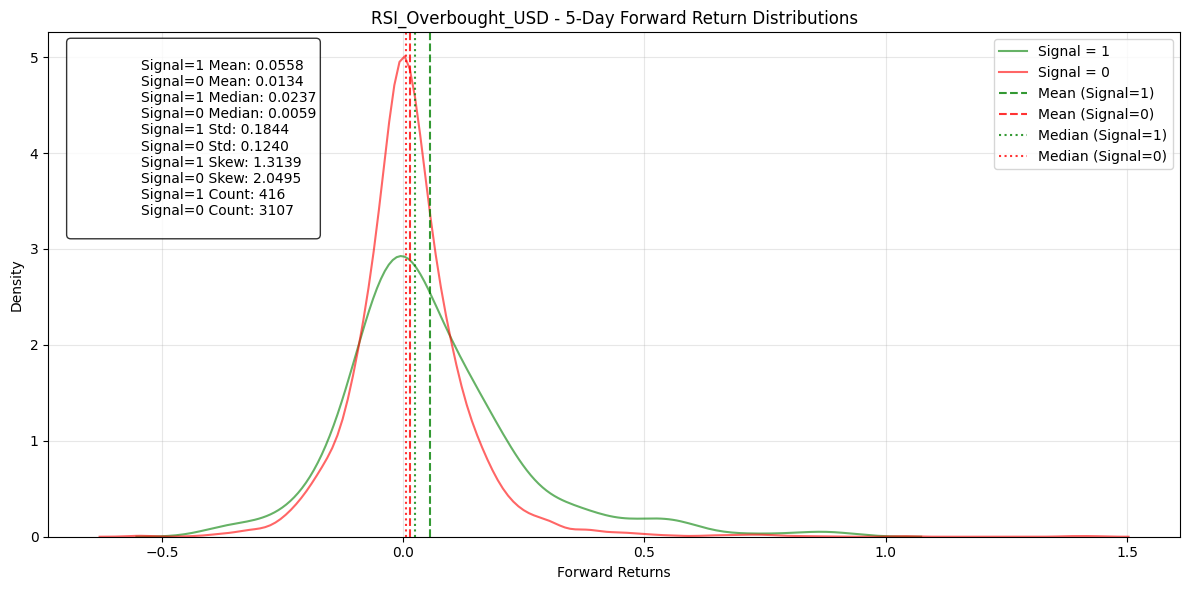


=== 7-Day Forward Returns Analysis ===
Signal=1 samples: 416, Signal=0 samples: 3105

Effectiveness Summary for 7-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.3416

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0547
  Effect size: 0.3416

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0003
  Median difference: 0.0158

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1632

Skewness & Kurtosis:
  Signal=1 skew: 1.4063
  Signal=0 skew: 1.9194
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


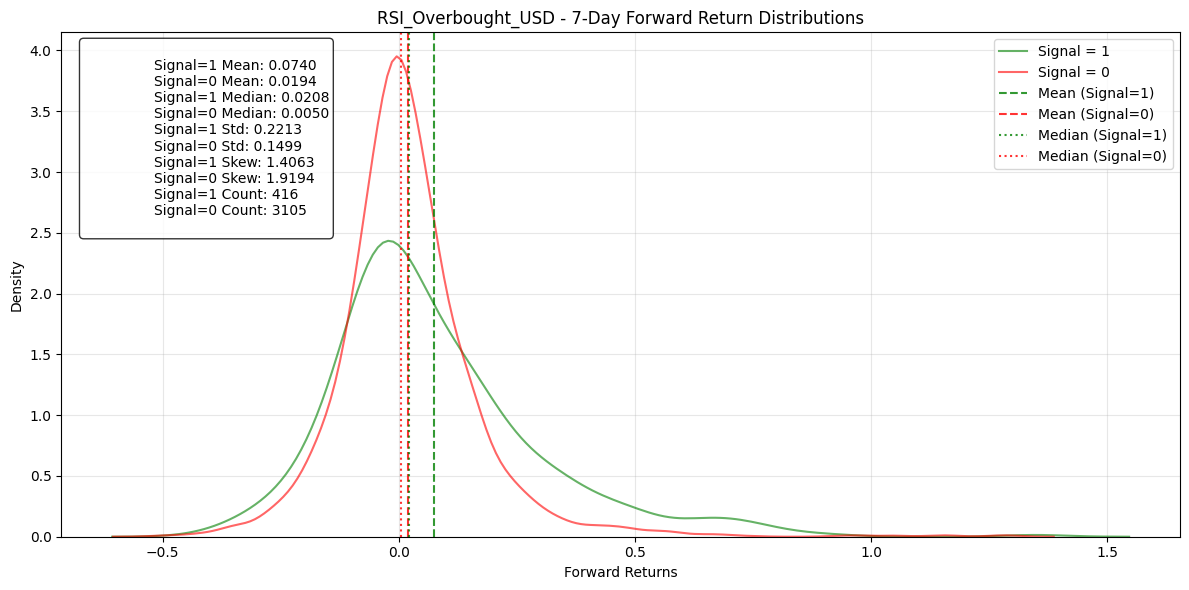


=== 14-Day Forward Returns Analysis ===
Signal=1 samples: 416, Signal=0 samples: 3098

Effectiveness Summary for 14-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.4678

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.1160
  Effect size: 0.4678

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0509

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1663

Skewness & Kurtosis:
  Signal=1 skew: 1.3723
  Signal=0 skew: 1.8423
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


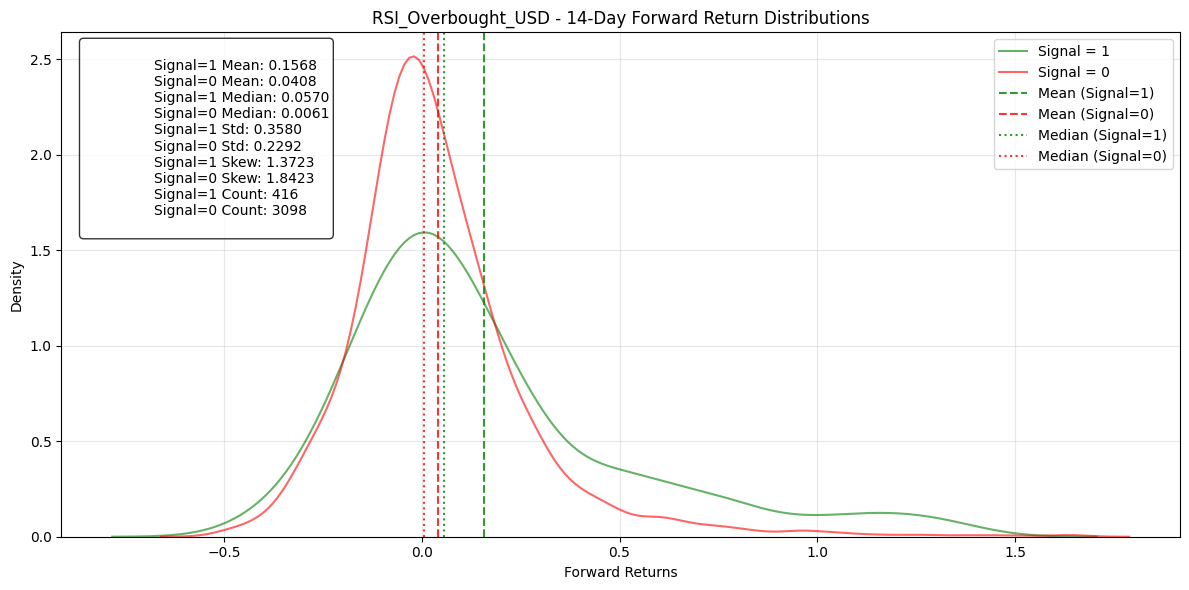


=== 30-Day Forward Returns Analysis ===
Signal=1 samples: 416, Signal=0 samples: 3082

Effectiveness Summary for 30-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.6181

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.3007
  Effect size: 0.6181

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0820

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1642

Skewness & Kurtosis:
  Signal=1 skew: 1.7952
  Signal=0 skew: 2.5720
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


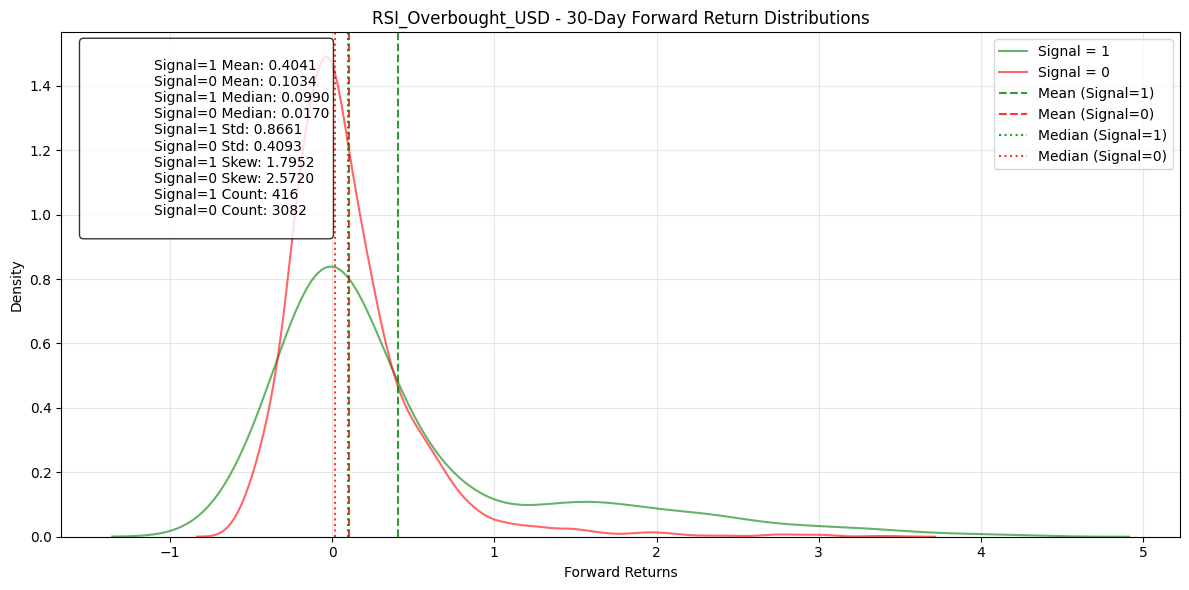


=== OVERALL SUMMARY ===
Signal: RSI_Overbought_USD
Effective periods: 5/5
Effectiveness ratio: 1.0000
Average effect size: 0.4070
Average confidence: 1.0000
Average mean difference: 0.1085
Overall effectiveness: True
Weight: 2.6739


ANALYZING RSI Bullish SIGNAL
Signal distribution: 1623 positive (1), 1905 negative (0), 3528 total
We have enough samples for analysis!

=== 3-Day Forward Returns Analysis ===
Signal=1 samples: 1623, Signal=0 samples: 1902

Effectiveness Summary for 3-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.2334

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0234
  Effect size: 0.2334

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0104

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1072

Skewness & Kurtosis:
  Signal=1 skew: 1.4847
  Signal=0 skew: 3.1297
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


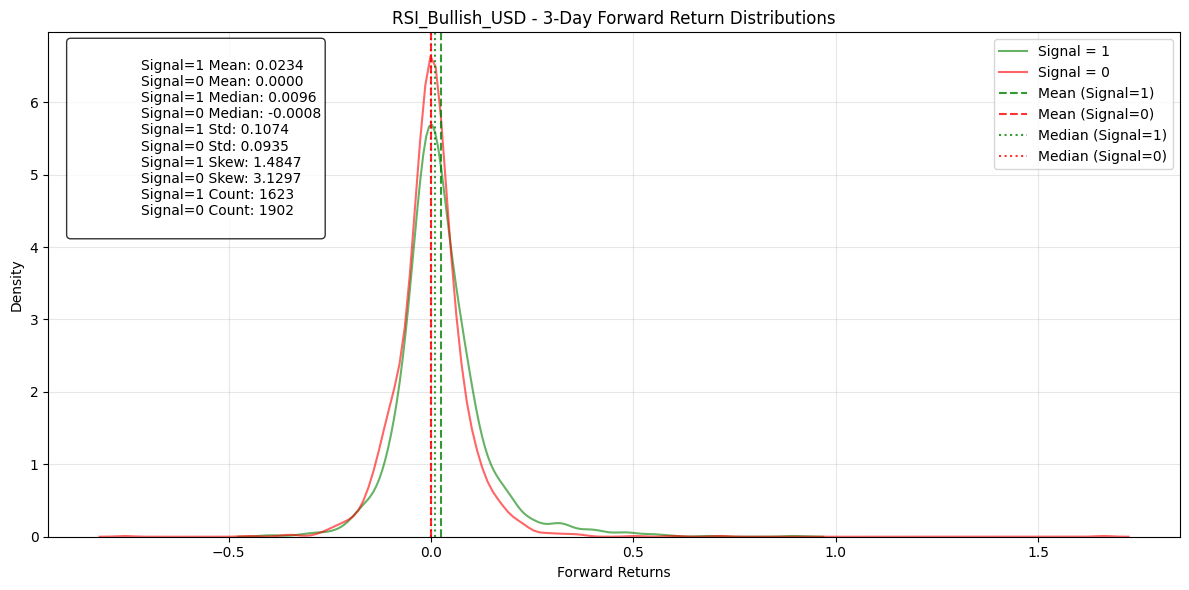


=== 5-Day Forward Returns Analysis ===
Signal=1 samples: 1623, Signal=0 samples: 1900

Effectiveness Summary for 5-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.2740

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0362
  Effect size: 0.2740

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0150

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1191

Skewness & Kurtosis:
  Signal=1 skew: 1.8747
  Signal=0 skew: 1.9223
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


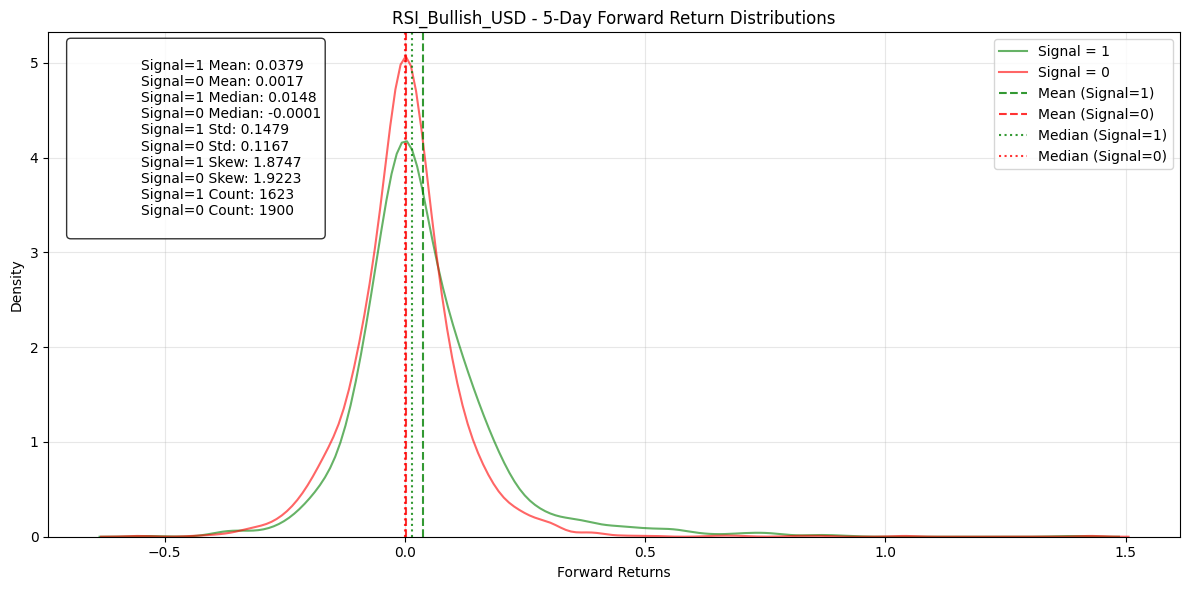


=== 7-Day Forward Returns Analysis ===
Signal=1 samples: 1623, Signal=0 samples: 1898

Effectiveness Summary for 7-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.3124

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0497
  Effect size: 0.3124

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0247

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1312

Skewness & Kurtosis:
  Signal=1 skew: 1.9487
  Signal=0 skew: 1.4299
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


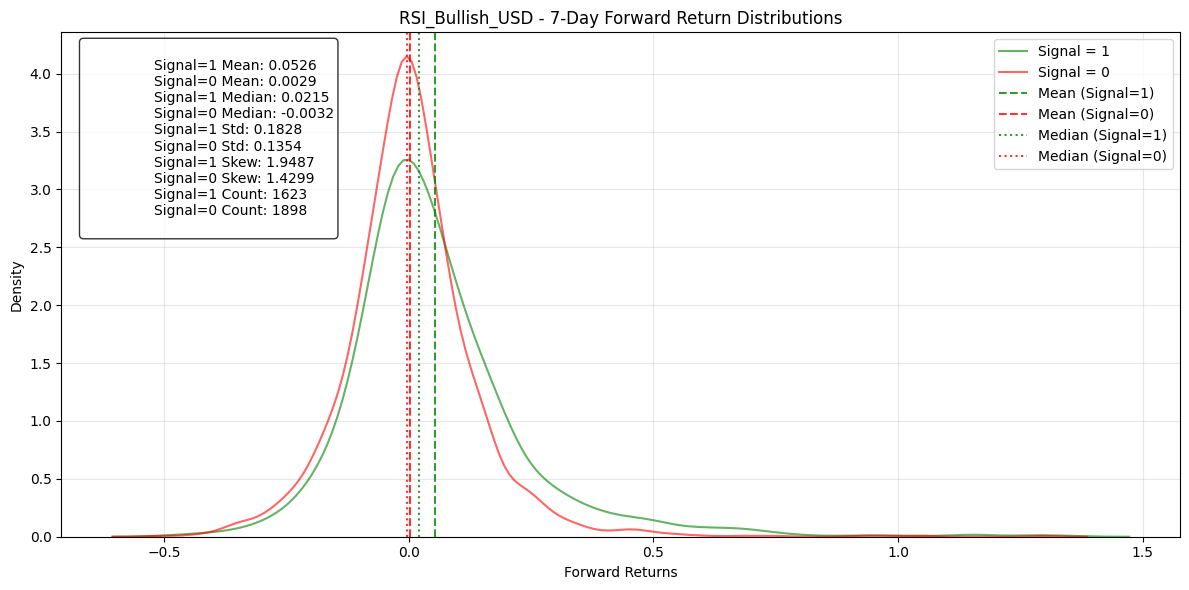


=== 14-Day Forward Returns Analysis ===
Signal=1 samples: 1623, Signal=0 samples: 1891

Effectiveness Summary for 14-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.3843

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.0947
  Effect size: 0.3843

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0515

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1400

Skewness & Kurtosis:
  Signal=1 skew: 1.8688
  Signal=0 skew: 1.0733
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


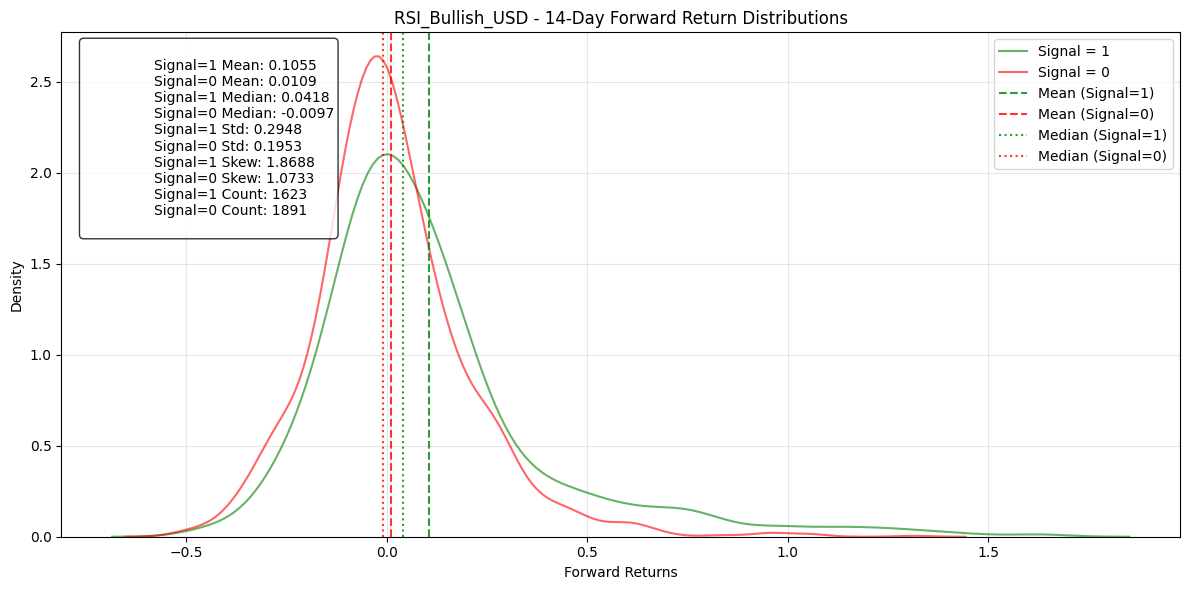


=== 30-Day Forward Returns Analysis ===
Signal=1 samples: 1623, Signal=0 samples: 1875

Effectiveness Summary for 30-day period:
Overall effective: True
Confidence: 1.0000
Effect size: 0.4026

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: 0.1958
  Effect size: 0.4026

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: 0.0675

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1163

Skewness & Kurtosis:
  Signal=1 skew: 2.5191
  Signal=0 skew: 1.1515
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


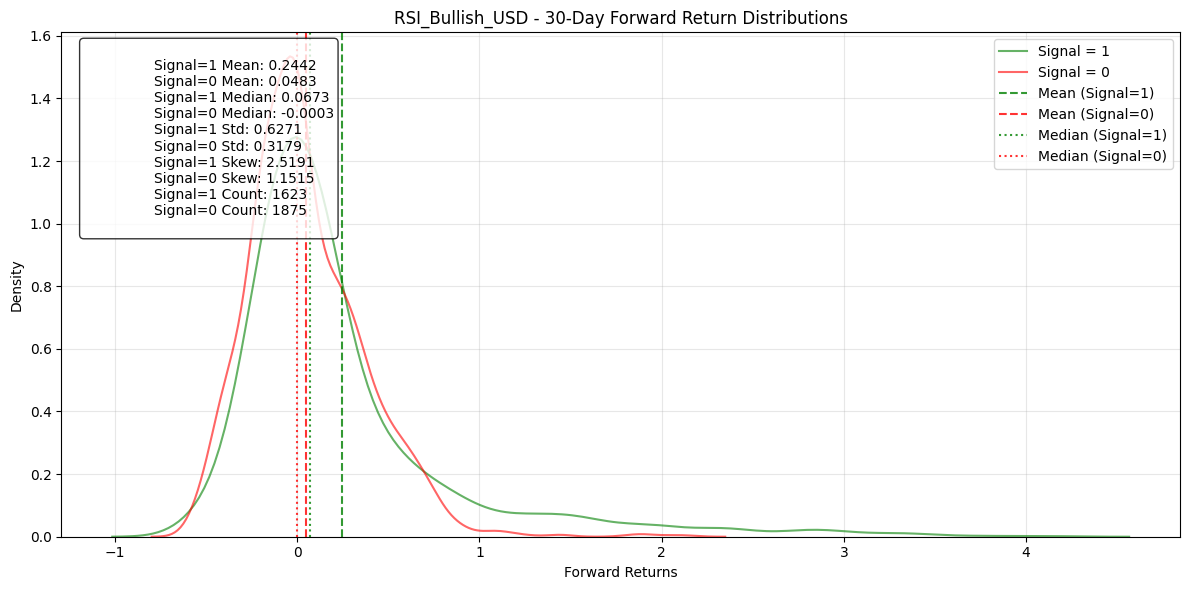


=== OVERALL SUMMARY ===
Signal: RSI_Bullish_USD
Effective periods: 5/5
Effectiveness ratio: 1.0000
Average effect size: 0.3213
Average confidence: 1.0000
Average mean difference: 0.0799
Overall effectiveness: True
Weight: 2.0595


ANALYZING RSI Bearish SIGNAL
Signal distribution: 1401 positive (1), 2127 negative (0), 3528 total
We have enough samples for analysis!

=== 3-Day Forward Returns Analysis ===
Signal=1 samples: 1398, Signal=0 samples: 2127

Effectiveness Summary for 3-day period:
Overall effective: False
Confidence: 1.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: -0.0187
  Effect size: -0.1866

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: -0.0089

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.0816

Skewness & Kurtosis:
  Signal=1 skew: 0.2541
  Signal=0 skew: 2.5876
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000

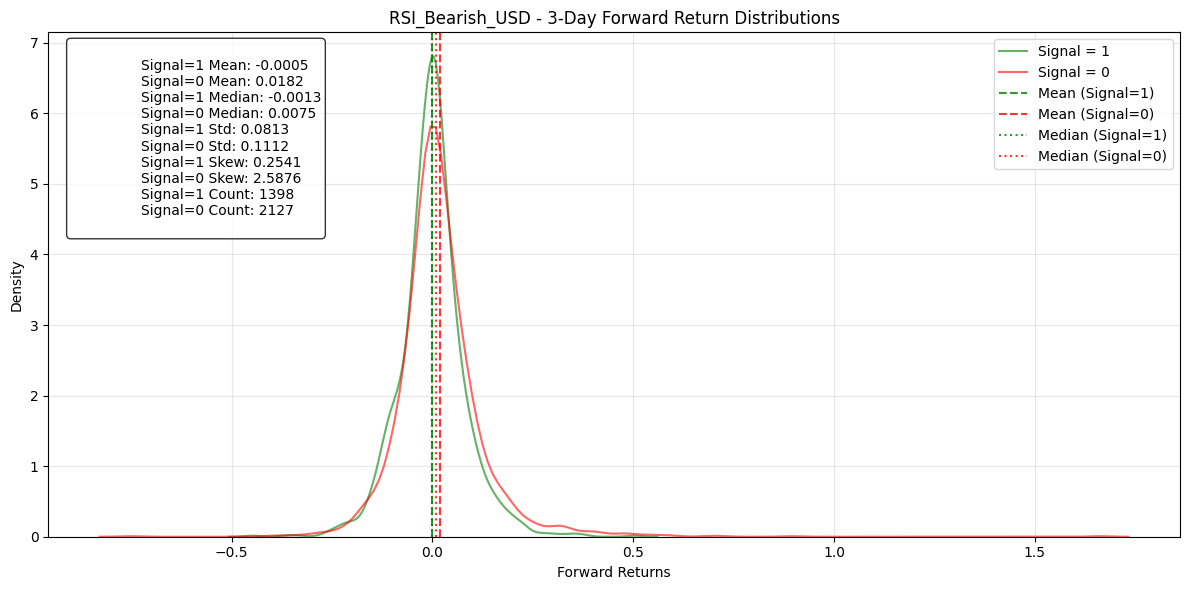


=== 5-Day Forward Returns Analysis ===
Signal=1 samples: 1396, Signal=0 samples: 2127

Effectiveness Summary for 5-day period:
Overall effective: False
Confidence: 1.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: -0.0311
  Effect size: -0.2346

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: -0.0131

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1056

Skewness & Kurtosis:
  Signal=1 skew: 1.1980
  Signal=0 skew: 2.0876
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


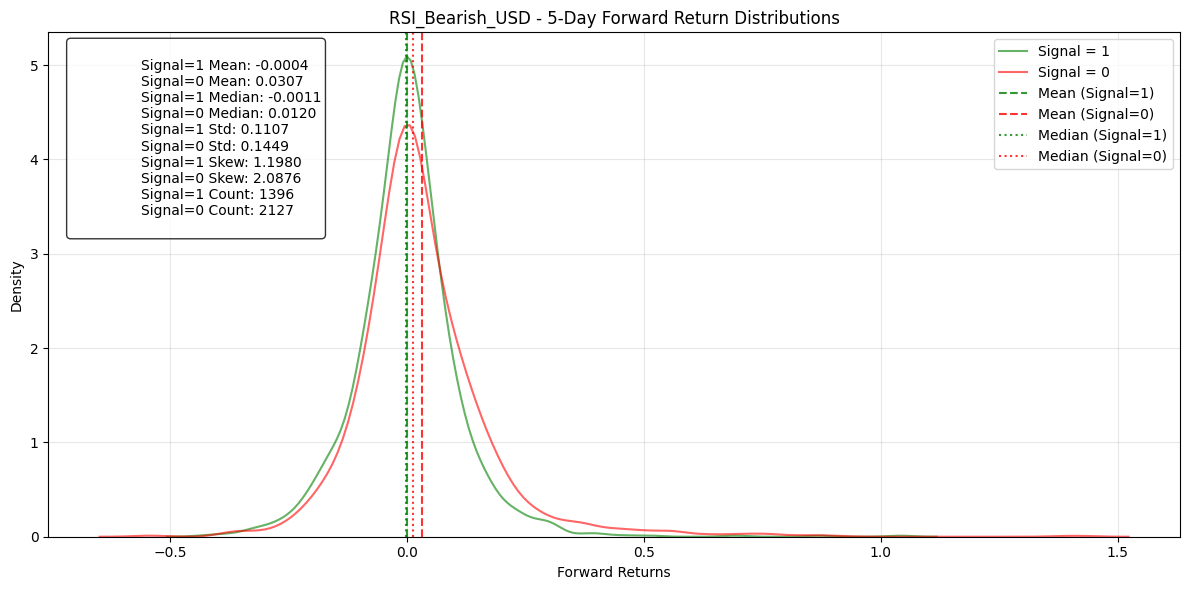


=== 7-Day Forward Returns Analysis ===
Signal=1 samples: 1394, Signal=0 samples: 2127

Effectiveness Summary for 7-day period:
Overall effective: False
Confidence: 1.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: -0.0427
  Effect size: -0.2677

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: -0.0186

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1183

Skewness & Kurtosis:
  Signal=1 skew: 1.6203
  Signal=0 skew: 1.9041
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


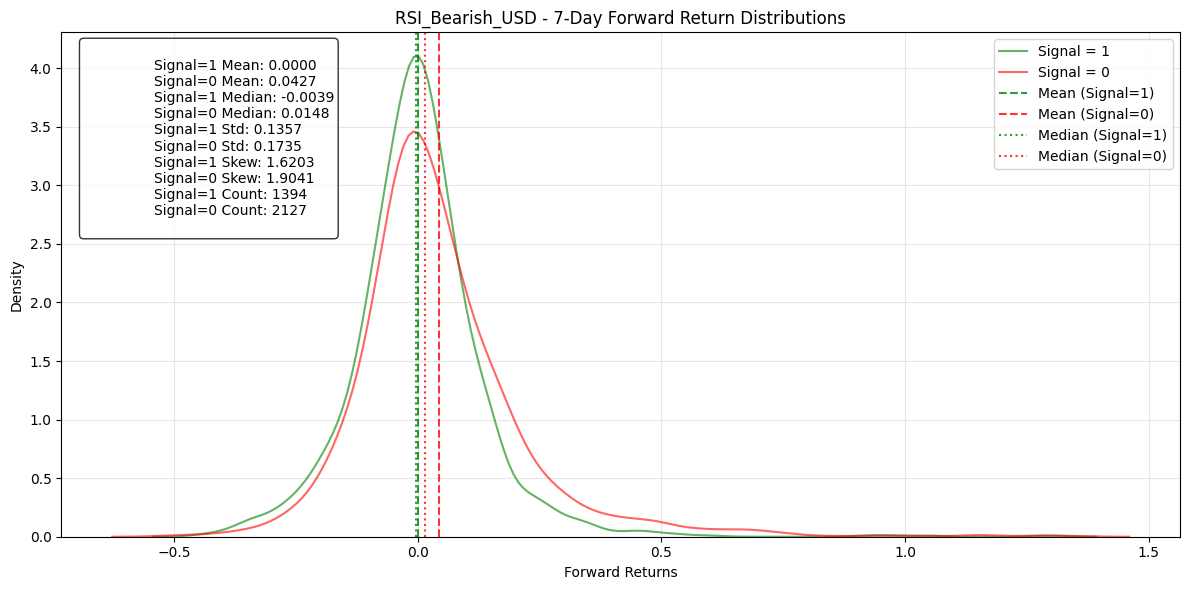


=== 14-Day Forward Returns Analysis ===
Signal=1 samples: 1387, Signal=0 samples: 2127

Effectiveness Summary for 14-day period:
Overall effective: False
Confidence: 1.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: -0.0740
  Effect size: -0.2981

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: -0.0387

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1098

Skewness & Kurtosis:
  Signal=1 skew: 1.2176
  Signal=0 skew: 1.8605
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


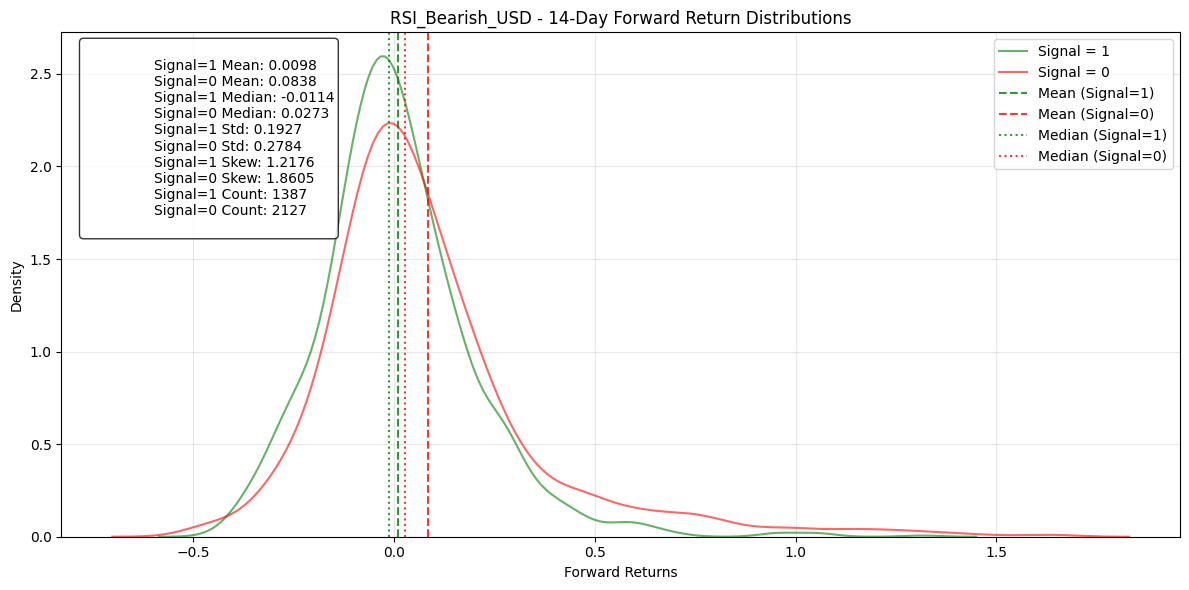


=== 30-Day Forward Returns Analysis ===
Signal=1 samples: 1371, Signal=0 samples: 2127

Effectiveness Summary for 30-day period:
Overall effective: False
Confidence: 1.0000
Effect size: 0.0000

T-test (mean comparison):
  Significant: True
  P-value: 0.0000
  Mean difference: -0.1584
  Effect size: -0.3233

Mann-Whitney (distribution comparison):
  Significant: True
  P-value: 0.0000
  Median difference: -0.0593

Kolmogorov-Smirnov (distribution shape):
  Significant: True
  P-value: 0.0000
  Statistic: 0.1099

Skewness & Kurtosis:
  Signal=1 skew: 1.0985
  Signal=0 skew: 2.6692
  Signal=1 kurt: 0.0000
  Signal=0 kurt: 0.0000


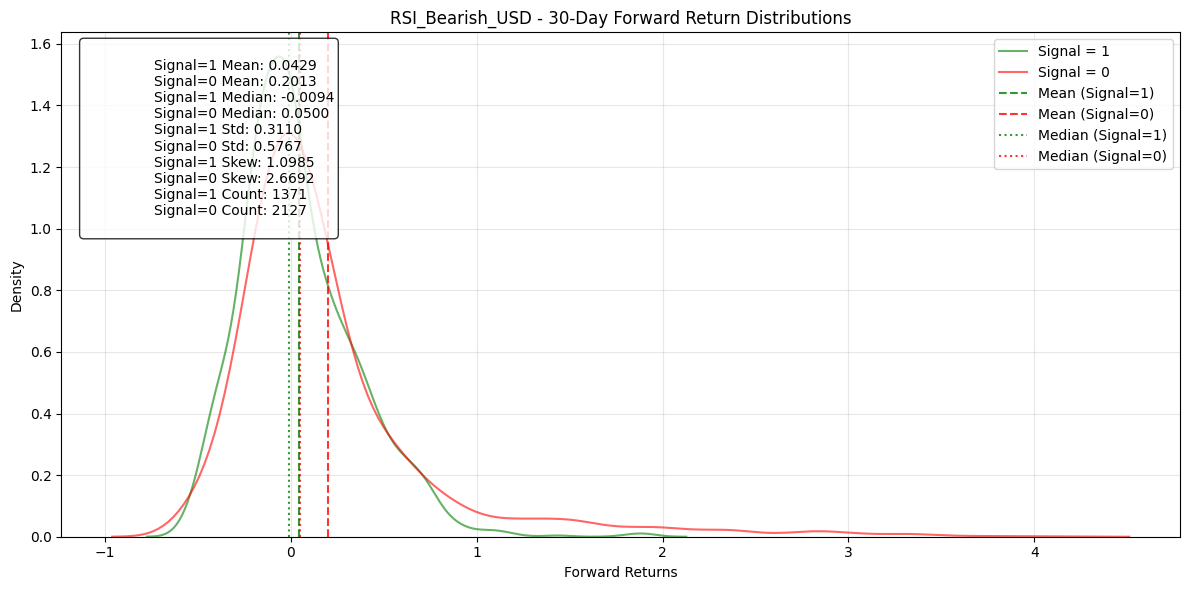


=== OVERALL SUMMARY ===
Signal: RSI_Bearish_USD
Effective periods: 0/5
Effectiveness ratio: 0.0000
Average effect size: 0.0000
Average confidence: 0.0000
Average mean difference: 0.0000
Overall effectiveness: False
Weight: 0.0000


In [21]:
# Comprehensive analysis of a single signal
asset = 'ethereum'

# Get data for Ethereum
eth_data = analyzer.get_asset_raw_data(asset)
print(f"Testing with {len(eth_data)} days of {asset} data")

# Create instances of RSI signals
rsi_oversold = RSI_Oversold_USD(params={'rsi_length': 14, 'oversold': 30})
rsi_overbought = RSI_Overbought_USD(params={'rsi_length': 14, 'overbought': 70})
rsi_bullish = RSI_Bullish_USD(params={'rsi_length': 14})
rsi_bearish = RSI_Bearish_USD(params={'rsi_length': 14})

# Calculate the signals
oversold_values = rsi_oversold.calculate(eth_data, asset)
overbought_values = rsi_overbought.calculate(eth_data, asset)
bullish_values = rsi_bullish.calculate(eth_data, asset)
bearish_values = rsi_bearish.calculate(eth_data, asset)

print(f"Oversold signal values: 1s: {sum(oversold_values == 1)}, 0s: {sum(oversold_values == 0)}")
print(f"Overbought signal values: 1s: {sum(overbought_values == 1)}, 0s: {sum(overbought_values == 0)}")
print(f"Bullish signal values: 1s: {sum(bullish_values == 1)}, 0s: {sum(bullish_values == 0)}")
print(f"Bearish signal values: 1s: {sum(bearish_values == 1)}, 0s: {sum(bearish_values == 0)}")

# Create our fixed calculator
calculator = BinaryForwardReturnsCalculator(periods=[3, 5, 7, 14, 30])

# Calculate forward returns
data_with_returns = calculator.calculate_forward_returns(eth_data, 'close')

# Set up statistical tester
from soros_system.analysis.forward_returns.statistical_tests import StatisticalTester
tester = StatisticalTester(alpha=0.05)

# Analyze both signals
for signal_name, signal_values in [("RSI Oversold", oversold_values), ("RSI Overbought", overbought_values), 
                                  ("RSI Bullish", bullish_values), ("RSI Bearish", bearish_values)]:
    print(f"\n\n{'='*50}")
    print(f"ANALYZING {signal_name} SIGNAL")
    print(f"{'='*50}")
    
    # Get conditional returns using our fixed method that understands 0/1 signals
    conditional_returns, sample_counts = calculator.get_conditional_returns(
        data_with_returns, signal_values, min_samples=30
    )
    
    # Check if we have sufficient samples
    if sample_counts['positive'] >= 20 and sample_counts['negative'] >= 20:
        print("We have enough samples for analysis!")
        
        # Initialize results storage
        all_test_results = {}
        
        # Analyze each period
        for period in calculator.periods:
            if period in conditional_returns and 'positive' in conditional_returns[period] and 'negative' in conditional_returns[period]:
                positive_returns = conditional_returns[period]['positive']
                negative_returns = conditional_returns[period]['negative']
                all_returns = conditional_returns[period]['all']
                
                print(f"\n=== {period}-Day Forward Returns Analysis ===")
                print(f"Signal=1 samples: {len(positive_returns)}, Signal=0 samples: {len(negative_returns)}")
                
                # Run all statistical tests
                test_results = tester.run_all_tests(positive_returns, negative_returns, all_returns)
                all_test_results[period] = test_results
                
                # Evaluate effectiveness
                effectiveness = tester.evaluate_signal_effectiveness(test_results)
                
                # Print results summary
                print(f"\nEffectiveness Summary for {period}-day period:")
                print(f"Overall effective: {effectiveness['overall_effective']}")
                print(f"Confidence: {effectiveness['confidence']:.4f}")
                print(f"Effect size: {effectiveness['effect_size']:.4f}")
                
                # T-test details
                if 't_test' in test_results and test_results['t_test'].get('valid', False):
                    t_test = test_results['t_test']
                    print(f"\nT-test (mean comparison):")
                    print(f"  Significant: {t_test.get('significant', False)}")
                    print(f"  P-value: {t_test.get('p_value', 'N/A'):.4f}")
                    print(f"  Mean difference: {t_test.get('mean_difference', 0):.4f}")
                    print(f"  Effect size: {t_test.get('effect_size', 0):.4f}")
                    
                # Mann-Whitney details  
                if 'mann_whitney' in test_results and test_results['mann_whitney'].get('valid', False):
                    mw_test = test_results['mann_whitney']
                    print(f"\nMann-Whitney (distribution comparison):")
                    print(f"  Significant: {mw_test.get('significant', False)}")
                    print(f"  P-value: {mw_test.get('p_value', 'N/A'):.4f}")
                    print(f"  Median difference: {mw_test.get('median_difference', 0):.4f}")
                
                # KS-test details
                if 'ks_test' in test_results and test_results['ks_test'].get('valid', False):
                    ks_test = test_results['ks_test']
                    print(f"\nKolmogorov-Smirnov (distribution shape):")
                    print(f"  Significant: {ks_test.get('significant', False)}")
                    print(f"  P-value: {ks_test.get('p_value', 'N/A'):.4f}")
                    print(f"  Statistic: {ks_test.get('statistic', 0):.4f}")
                
                # Skew & Kurt details
                if 'skew_kurt' in test_results and test_results['skew_kurt'].get('valid', False):
                    sk_test = test_results['skew_kurt']
                    print(f"\nSkewness & Kurtosis:")
                    print(f"  Signal=1 skew: {sk_test.get('positive_skew', 0):.4f}")
                    print(f"  Signal=0 skew: {sk_test.get('negative_skew', 0):.4f}")
                    print(f"  Signal=1 kurt: {sk_test.get('positive_kurt', 0):.4f}")
                    print(f"  Signal=0 kurt: {sk_test.get('negative_kurt', 0):.4f}")
                
                # Plot distributions
                plt.figure(figsize=(12, 6))
                sns.kdeplot(data=positive_returns, label='Signal = 1', color='green', alpha=0.6)
                sns.kdeplot(data=negative_returns, label='Signal = 0', color='red', alpha=0.6)
                
                # Add vertical lines for means and medians
                plt.axvline(positive_returns.mean(), color='green', linestyle='--', alpha=0.8, label='Mean (Signal=1)')
                plt.axvline(negative_returns.mean(), color='red', linestyle='--', alpha=0.8, label='Mean (Signal=0)')
                plt.axvline(positive_returns.median(), color='green', linestyle=':', alpha=0.8, label='Median (Signal=1)')
                plt.axvline(negative_returns.median(), color='red', linestyle=':', alpha=0.8, label='Median (Signal=0)')
                
                # Add title and labels
                signal_obj = None
                if signal_name == "RSI Oversold":
                    signal_obj = rsi_oversold
                elif signal_name == "RSI Overbought":
                    signal_obj = rsi_overbought
                elif signal_name == "RSI Bullish":
                    signal_obj = rsi_bullish
                elif signal_name == "RSI Bearish":
                    signal_obj = rsi_bearish
                    
                plt.title(f'{signal_obj.name} - {period}-Day Forward Return Distributions')
                plt.xlabel('Forward Returns')
                plt.ylabel('Density')
                plt.legend()
                
                # Add statistical annotations
                stats_text = f"""
                Signal=1 Mean: {positive_returns.mean():.4f}
                Signal=0 Mean: {negative_returns.mean():.4f}
                Signal=1 Median: {positive_returns.median():.4f}
                Signal=0 Median: {negative_returns.median():.4f}
                Signal=1 Std: {positive_returns.std():.4f}
                Signal=0 Std: {negative_returns.std():.4f}
                Signal=1 Skew: {stats.skew(positive_returns):.4f}
                Signal=0 Skew: {stats.skew(negative_returns):.4f}
                Signal=1 Count: {len(positive_returns)}
                Signal=0 Count: {len(negative_returns)}
                """
                plt.text(0.02, 0.98, stats_text,
                         transform=plt.gca().transAxes,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
        
        # Calculate overall effectiveness
        effective_periods = 0
        total_periods = len(all_test_results)
        effect_sizes = []
        confidences = []
        mean_diffs = []
        
        for period, test_results in all_test_results.items():
            effectiveness = tester.evaluate_signal_effectiveness(test_results)
            if effectiveness.get('overall_effective', False):
                effective_periods += 1
                effect_sizes.append(abs(effectiveness.get('effect_size', 0.0)))
                confidences.append(effectiveness.get('confidence', 0.0))
                
                if 't_test' in test_results and test_results['t_test'].get('valid', False):
                    mean_diffs.append(test_results['t_test'].get('mean_difference', 0))
        
        # Calculate summary metrics
        effectiveness_ratio = effective_periods / total_periods if total_periods > 0 else 0.0
        avg_effect_size = np.mean(effect_sizes) if effect_sizes else 0.0
        avg_confidence = np.mean(confidences) if confidences else 0.0
        avg_mean_diff = np.mean(mean_diffs) if mean_diffs else 0.0
        
        # Determine overall effectiveness
        overall_effective = effectiveness_ratio >= 0.5 and avg_effect_size > 0.15
        
        # Calculate weight
        if overall_effective:
            weight = (avg_effect_size * 0.5) + (avg_confidence * 0.3) + (abs(avg_mean_diff) * 100 * 0.2)
        else:
            weight = (avg_effect_size * 0.25) + (avg_confidence * 0.15) + (abs(avg_mean_diff) * 100 * 0.1)
            if effectiveness_ratio < 0.3 or avg_effect_size < 0.1:
                weight = 0.0
        
        # Print overall summary
        signal_obj = None
        if signal_name == "RSI Oversold":
            signal_obj = rsi_oversold
        elif signal_name == "RSI Overbought":
            signal_obj = rsi_overbought
        elif signal_name == "RSI Bullish":
            signal_obj = rsi_bullish
        elif signal_name == "RSI Bearish":
            signal_obj = rsi_bearish
            
        print("\n=== OVERALL SUMMARY ===")
        print(f"Signal: {signal_obj.name}")
        print(f"Effective periods: {effective_periods}/{total_periods}")
        print(f"Effectiveness ratio: {effectiveness_ratio:.4f}")
        print(f"Average effect size: {avg_effect_size:.4f}")
        print(f"Average confidence: {avg_confidence:.4f}")
        print(f"Average mean difference: {avg_mean_diff:.4f}")
        print(f"Overall effectiveness: {overall_effective}")
        print(f"Weight: {weight:.4f}")
        
    else:
        print("Not enough samples for analysis")